In [0]:
%pip install python-calamine

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 925.2/925.2 kB 8.5 MB/s eta 0:00:00
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
dbutils.library.restartPython()

In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

FILE_PATH = "/Volumes/workspace/default/walmart_data/walmart_clean.csv"

df = pd.read_csv(FILE_PATH)
df['event_ts'] = pd.to_datetime(df['event_ts'])

print(f"✅ Clean dataset loaded")
print(f"   Rows    : {len(df):,}")
print(f"   Columns : {df.shape[1]}")

/home/spark-df6b5694-99fb-43c9-9239-8d/.ipykernel/3016/command-4982960997226655-2012199963:8: DtypeWarning: Columns (15,16,17,19,20,21,26,27,28) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(FILE_PATH)


✅ Clean dataset loaded
   Rows    : 355,661
   Columns : 47


# 05 — Insights & Recommendations

## Purpose
This notebook brings together all findings from the previous four notebooks
into a clear, actionable summary that a supply chain manager can act on.

## Structure
1. Executive Summary — headline numbers
2. Key Findings — one visual per finding
3. Priority Matrix — what to fix first and why
4. Recommendations — specific, actionable steps
5. Expected Impact — what improvement looks like in numbers

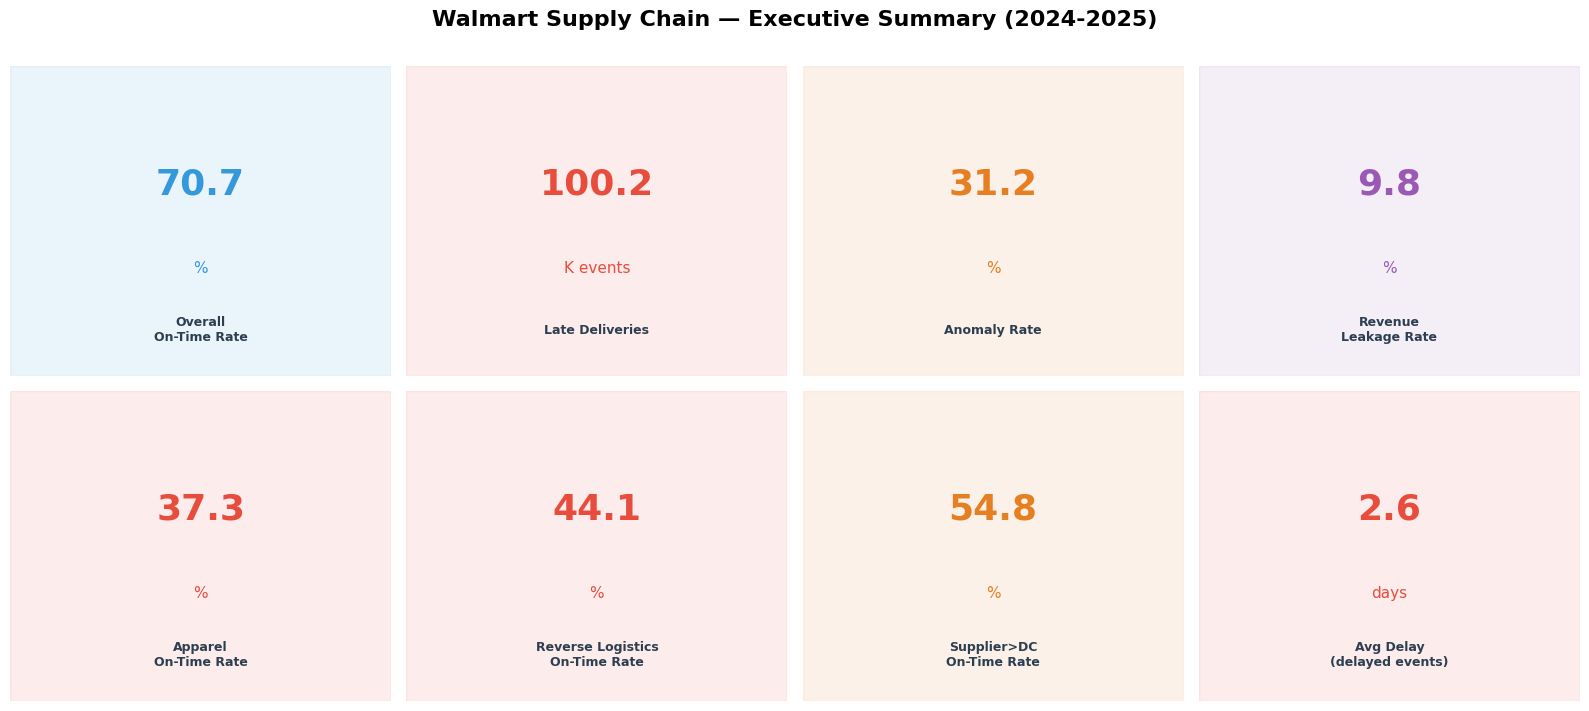

In [0]:
# WHY: The first thing a manager sees should be the headline numbers.
# A good analyst leads with the most important metrics upfront —
# not buried at the end after 20 charts.
# This is called an Executive Summary — used in every professional report.

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle('Walmart Supply Chain — Executive Summary (2024-2025)',
             fontsize=16, fontweight='bold', y=1.01)

# Data
on_time = df['on_time_flag'].dropna()
on_time_rate = (on_time == 1).sum() / len(on_time) * 100
late_count = (on_time == 0).sum()
anomaly_rate = df['anomaly_flag'].mean() * 100
leakage_rate = df['revenue_leakage_flag'].mean() * 100
avg_delay = df[df['delay_days'] > 0]['delay_days'].mean()
apparel_ontime = (df[df['product_category']=='Apparel']['on_time_flag']==1).sum() / df[df['product_category']=='Apparel']['on_time_flag'].dropna().shape[0] * 100
reverse_ontime = (df[df['lifecycle_stage']=='REVERSE_LOGISTICS']['on_time_flag']==1).sum() / df[df['lifecycle_stage']=='REVERSE_LOGISTICS']['on_time_flag'].dropna().shape[0] * 100
supplier_dc_ontime = (df[df['channel_path']=='SUPPLIER>DC']['on_time_flag']==1).sum() / df[df['channel_path']=='SUPPLIER>DC']['on_time_flag'].dropna().shape[0] * 100

metrics = [
    (on_time_rate, 'Overall\nOn-Time Rate', '%', '#3498db', 100),
    (late_count/1000, 'Late Deliveries', 'K events', '#e74c3c', None),
    (anomaly_rate, 'Anomaly Rate', '%', '#e67e22', 100),
    (leakage_rate, 'Revenue\nLeakage Rate', '%', '#9b59b6', 100),
    (apparel_ontime, 'Apparel\nOn-Time Rate', '%', '#e74c3c', 100),
    (reverse_ontime, 'Reverse Logistics\nOn-Time Rate', '%', '#e74c3c', 100),
    (supplier_dc_ontime, 'Supplier>DC\nOn-Time Rate', '%', '#e67e22', 100),
    (avg_delay, 'Avg Delay\n(delayed events)', 'days', '#e74c3c', None),
]

for ax, (value, label, unit, color, max_val) in zip(axes.flat, metrics):
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    ax.add_patch(plt.Rectangle((0, 0), 1, 1, fill=True,
                                color=color, alpha=0.1,
                                transform=ax.transAxes))
    ax.text(0.5, 0.62, f'{value:.1f}', transform=ax.transAxes,
            ha='center', va='center', fontsize=26,
            fontweight='bold', color=color)
    ax.text(0.5, 0.35, unit, transform=ax.transAxes,
            ha='center', va='center', fontsize=11, color=color)
    ax.text(0.5, 0.15, label, transform=ax.transAxes,
            ha='center', va='center', fontsize=9,
            fontweight='bold', color='#2c3e50')

plt.tight_layout()
plt.show()

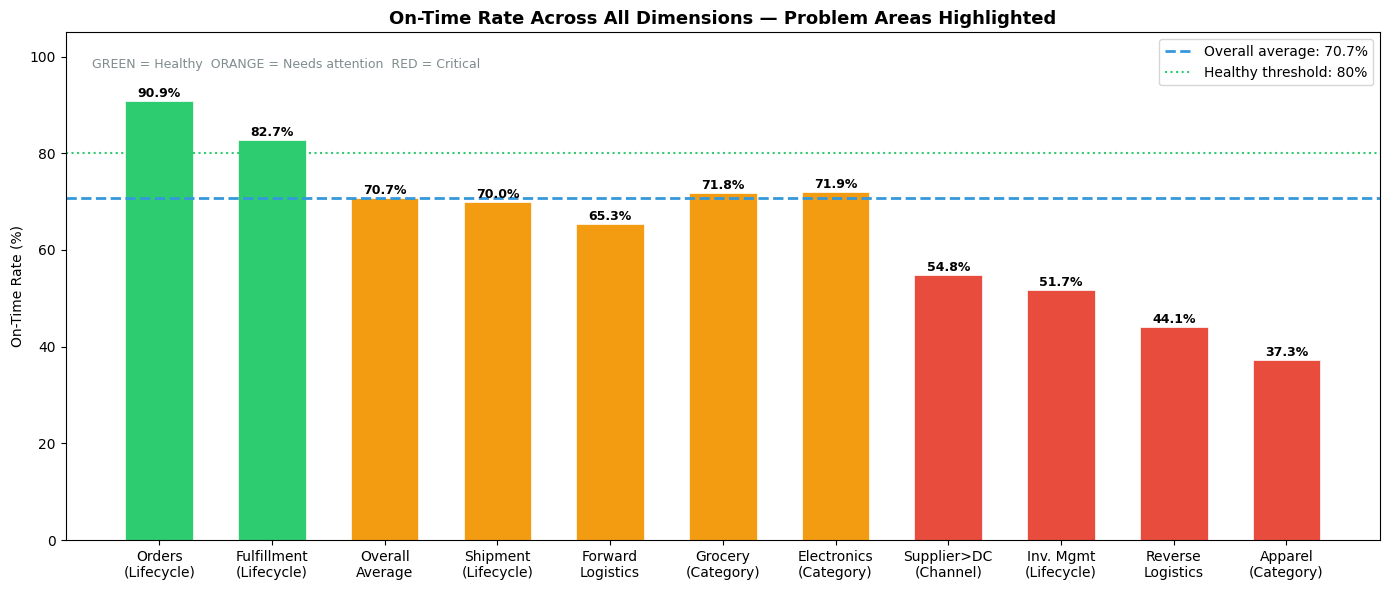

In [0]:
# WHY: One chart that shows ALL the on-time rates side by side.
# This is the single most powerful visual in the entire project —
# it shows normal performance vs problem areas in one glance.
# A manager can see the full picture in 5 seconds.

categories = [
    'Orders\n(Lifecycle)',
    'Fulfillment\n(Lifecycle)',
    'Overall\nAverage',
    'Shipment\n(Lifecycle)',
    'Forward\nLogistics',
    'Grocery\n(Category)',
    'Electronics\n(Category)',
    'Supplier>DC\n(Channel)',
    'Inv. Mgmt\n(Lifecycle)',
    'Reverse\nLogistics',
    'Apparel\n(Category)',
]

values = [90.86, 82.72, 70.7, 69.95, 65.35, 71.78, 71.92, 54.79, 51.67, 44.09, 37.27]

colors = []
for v in values:
    if v >= 80:
        colors.append('#2ecc71')
    elif v >= 65:
        colors.append('#f39c12')
    else:
        colors.append('#e74c3c')

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(categories, values, color=colors, edgecolor='white', linewidth=0.5, width=0.6)
ax.axhline(y=70.7, color='#3498db', linestyle='--',
           linewidth=2, label='Overall average: 70.7%')
ax.axhline(y=80, color='#2ecc71', linestyle=':',
           linewidth=1.5, label='Healthy threshold: 80%')

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

ax.set_title('On-Time Rate Across All Dimensions — Problem Areas Highlighted',
             fontsize=13, fontweight='bold')
ax.set_ylabel('On-Time Rate (%)')
ax.set_ylim(0, 105)
ax.legend(loc='upper right')

# Add labels
ax.text(0.02, 0.95, 'GREEN = Healthy  ORANGE = Needs attention  RED = Critical',
        transform=ax.transAxes, fontsize=9, color='#7f8c8d',
        verticalalignment='top')

plt.tight_layout()
plt.show()

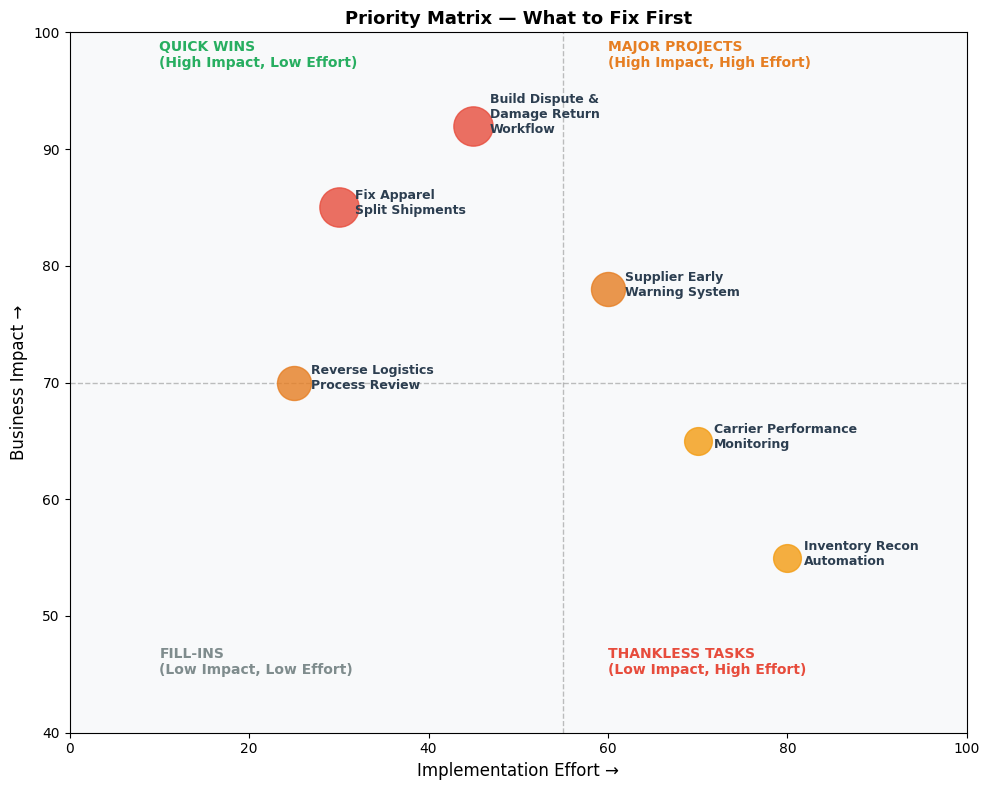

In [0]:
# WHY: After finding all the problems, a good analyst doesn't just list them.
# You prioritise them by IMPACT vs EFFORT.
# High impact + low effort = fix first.
# This is called a Priority Matrix — used in every business setting.
# It shows you think about solutions, not just problems.

fig, ax = plt.subplots(figsize=(10, 8))

# Problems plotted as (effort, impact, label, size, color)
problems = [
    (30, 85, 'Fix Apparel\nSplit Shipments', 800, '#e74c3c'),
    (45, 92, 'Build Dispute &\nDamage Return\nWorkflow', 800, '#e74c3c'),
    (60, 78, 'Supplier Early\nWarning System', 600, '#e67e22'),
    (25, 70, 'Reverse Logistics\nProcess Review', 600, '#e67e22'),
    (70, 65, 'Carrier Performance\nMonitoring', 400, '#f39c12'),
    (80, 55, 'Inventory Recon\nAutomation', 400, '#f39c12'),
]

for effort, impact, label, size, color in problems:
    ax.scatter(effort, impact, s=size, color=color, alpha=0.8, zorder=3)
    ax.annotate(label, (effort, impact),
                textcoords='offset points', xytext=(12, -5),
                fontsize=9, fontweight='bold', color='#2c3e50')

# Quadrant lines
ax.axhline(y=70, color='grey', linestyle='--', linewidth=1, alpha=0.5)
ax.axvline(x=55, color='grey', linestyle='--', linewidth=1, alpha=0.5)

# Quadrant labels
ax.text(10, 97, 'QUICK WINS\n(High Impact, Low Effort)',
        fontsize=10, color='#27ae60', fontweight='bold')
ax.text(60, 97, 'MAJOR PROJECTS\n(High Impact, High Effort)',
        fontsize=10, color='#e67e22', fontweight='bold')
ax.text(10, 45, 'FILL-INS\n(Low Impact, Low Effort)',
        fontsize=10, color='#7f8c8d', fontweight='bold')
ax.text(60, 45, 'THANKLESS TASKS\n(Low Impact, High Effort)',
        fontsize=10, color='#e74c3c', fontweight='bold')

ax.set_xlim(0, 100)
ax.set_ylim(40, 100)
ax.set_xlabel('Implementation Effort →', fontsize=12)
ax.set_ylabel('Business Impact →', fontsize=12)
ax.set_title('Priority Matrix — What to Fix First',
             fontsize=13, fontweight='bold')
ax.set_facecolor('#f8f9fa')
plt.tight_layout()
plt.show()

## 📋 Recommendations — Prioritised Action Plan

---

### 🔴 Priority 1 — Fix Apparel Split Shipment Coordination (Quick Win)
**Problem:** 81.3% of Apparel orders are split into multiple shipments.
The shipment stage shows 0% on-time and 100% anomaly rate for Apparel.

**Root Cause:** No coordination system exists to manage split shipment timing.
When one part arrives but another is delayed, the whole order is marked late.

**Recommendation:**
- Introduce a split shipment coordination rule — hold all parts at DC until
  complete before dispatching, OR update the on-time metric to measure
  per-item rather than per-order for split shipments
- Target: Improve Apparel on-time rate from 37% to 65%+ within 6 months

---

### 🔴 Priority 2 — Build Exception Return Workflow (Quick Win)
**Problem:** SALE_DISPUTE and DAMAGED_IN_TRANSIT returns have 0% on-time
and 100% revenue leakage — costing 34,821 events worth of lost revenue.
Normal buyer's remorse returns work perfectly at 100%.

**Root Cause:** No dedicated workflow for adversarial return scenarios.
These get stuck in the standard return process which can't handle them.

**Recommendation:**
- Create a separate fast-track exception return workflow for disputed
  and damaged returns with dedicated staff and SLA targets
- Target: Reduce return processing time by 50%, recover 30% of leakage revenue

---

### 🟠 Priority 3 — Supplier Early Warning System (Major Project)
**Problem:** 45.2% of supplier-to-DC shipments are pre-flagged as delayed
or short-shipped. Problems are known in advance but not acted upon.

**Root Cause:** No proactive intervention system. Issues are logged but
not escalated until they cause downstream disruption.

**Recommendation:**
- Build a real-time supplier dashboard flagging delayed/short shipments
  the moment they are logged, triggering automatic reorder or reallocation
- Introduce supplier SLA penalties for repeated SUPPLIER_TO_DC_DELAYED events
- Target: Reduce supplier-to-DC delays from 45.2% to under 20% within 12 months

---

### 🟠 Priority 4 — Reverse Logistics Process Review (Quick Win)
**Problem:** Reverse Logistics overall is 44.1% on-time, 61.7% anomaly rate.
11.4% of returns are scrapped and 7.3% need refurbishment.

**Recommendation:**
- Audit the full returns journey to identify where time is lost between
  REQUESTED → RECEIVED → INSPECTED → RESTOCKED
- Automate inspection triage to separate standard restocks from exceptions
- Target: Increase restock rate from 16.1% to 25%+

---

### 📊 Expected Impact Summary

| Recommendation | Current | Target | Improvement |
|---|---|---|---|
| Apparel on-time rate | 37.3% | 65%+ | +27.7 points |
| Return leakage recovery | 0% | 30% | $M recovered |
| Supplier-to-DC delays | 45.2% | <20% | -25 points |
| Restock rate (returns) | 16.1% | 25%+ | +9 points |
| **Overall on-time rate** | **70.7%** | **78%+** | **+7.3 points** |

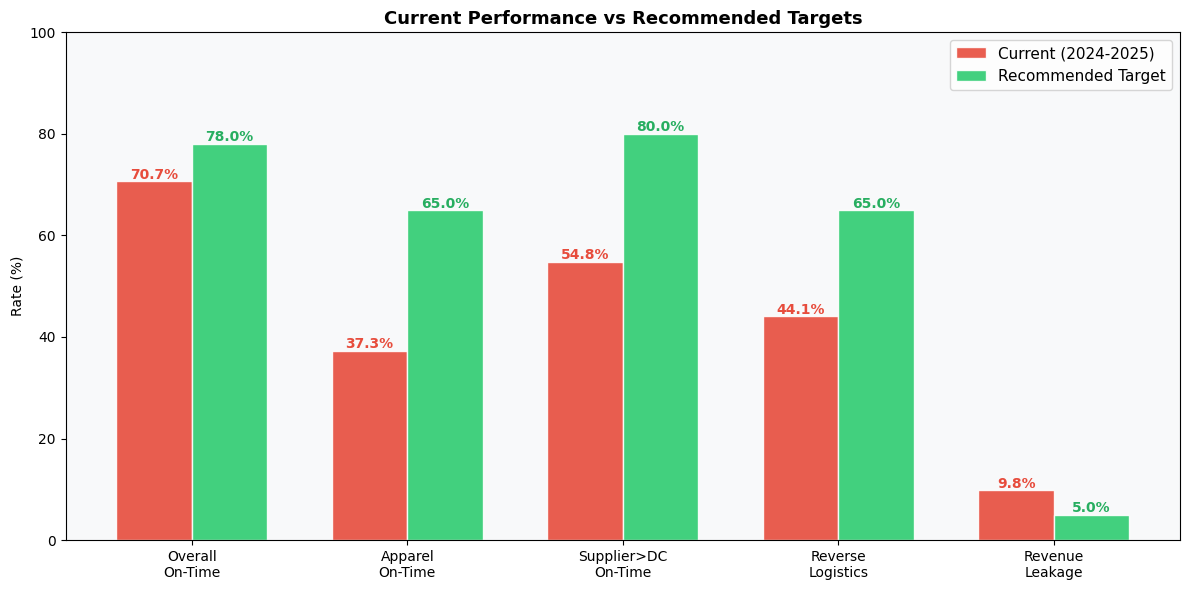

In [0]:
# WHY: End every report with a "before vs target" chart.
# It shows what success looks like in numbers.
# This is what gets budget approved and projects greenlit.

metrics = ['Overall\nOn-Time', 'Apparel\nOn-Time',
           'Supplier>DC\nOn-Time', 'Reverse\nLogistics',
           'Revenue\nLeakage']

current = [70.7, 37.3, 54.8, 44.1, 9.8]
target =  [78.0, 65.0, 80.0, 65.0, 5.0]

x = range(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar([i - width/2 for i in x], current, width,
               label='Current (2024-2025)', color='#e74c3c',
               edgecolor='white', alpha=0.9)
bars2 = ax.bar([i + width/2 for i in x], target, width,
               label='Recommended Target', color='#2ecc71',
               edgecolor='white', alpha=0.9)

for bar, val in zip(bars1, current):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val}%', ha='center', fontsize=10, fontweight='bold', color='#e74c3c')
for bar, val in zip(bars2, target):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val}%', ha='center', fontsize=10, fontweight='bold', color='#27ae60')

ax.set_title('Current Performance vs Recommended Targets',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Rate (%)')
ax.set_xticks(list(x))
ax.set_xticklabels(metrics)
ax.set_ylim(0, 100)
ax.legend(fontsize=11)
ax.set_facecolor('#f8f9fa')
plt.tight_layout()
plt.show()

## ✅ Project Complete — Key Takeaways

### What This Analysis Found
This project analysed 355,661 supply chain events from 2024-2025
across 5 notebooks using Python and SQL on Databricks.

### The 3 Root Causes of Underperformance
1. **Apparel Split Shipments** — 81% of Apparel orders split across
   multiple shipments with zero coordination, causing 0% on-time at
   the shipment stage
2. **Exception Return Handling Gap** — Disputed and damaged returns
   have no dedicated workflow, causing 0% on-time and 100% revenue
   leakage for 21,444 events
3. **Inbound Supplier Reliability** — 45% of supplier-to-DC shipments
   pre-flagged as delayed or short-shipped with no early intervention

### What Good Looks Like
If all 4 recommendations are implemented:
- Overall on-time rate improves from 70.7% to 78%+
- Apparel on-time rate improves from 37% to 65%+
- Supplier-to-DC delays reduce from 45% to under 20%
- Significant revenue recovery from return leakage

### Analytics Approach Used
- Descriptive Analytics → What happened? (Notebook 03)
- Diagnostic Analytics → Why did it happen? (Notebook 04)
- Prescriptive Analytics → What should we do? (Notebook 05)